# Exploración inicial: California Housing Dataset

**Curso:** Visualización de Datos y Gerencia de la Información (UNAULA)

## ¿Qué vas a encontrar en este notebook?

Este notebook hace una primera exploración del dataset California Housing: variables geográficas, demográficas y de vivienda por bloque censal, con el objetivo de más adelante explicar `median_house_value` (el valor mediano de vivienda de cada bloque).

Es una exploración de diagnóstico. En ninguna celda se limpian, imputan ni eliminan datos todavía. Al terminar deberías tener claro qué problemas de calidad tiene el dataset y qué patrones muestra, antes de tocar nada.

## Cómo leer cada sección

Cada bloque de análisis sigue la misma estructura:
1. **Propósito** (celda de texto): qué vamos a mirar y por qué.
2. **Código**: la celda que produce el resultado.
3. **Conclusión** (celda de texto): qué dice ese resultado concreto sobre este dataset.

## Columnas del dataset

| Columna | Significado |
|---|---|
| `longitude`, `latitude` | Coordenadas geográficas del bloque censal |
| `housing_median_age` | Edad mediana de las viviendas del bloque |
| `total_rooms`, `total_bedrooms` | Total de habitaciones/dormitorios del bloque (no por vivienda) |
| `population`, `households` | Población y hogares del bloque |
| `median_income` | Ingreso mediano del bloque (en decenas de miles de USD) |
| `median_house_value` | Variable objetivo: valor mediano de vivienda del bloque |
| `ocean_proximity` | Categórica: cercanía del bloque al océano |

## 1. Carga y estructura del dataset

**Propósito:** confirmar que el archivo cargó completo y que los tipos de dato son los esperados, por ejemplo que ninguna columna numérica llegó como texto.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.float_format", lambda x: f"{x:.2f}")

df = pd.read_csv(os.path.join("data", "housing.csv"))
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY


In [17]:
# Forma del dataset (filas x columnas), tipos de dato y resumen general (nulos, memoria)
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
df.info()

Shape: (20640, 10)

Dtypes:
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocea

In [18]:
# Primeras y últimas filas: útil para detectar si el archivo viene ordenado por alguna columna
display(df.head())
display(df.tail())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.00,1665.00,374.00,845.00,330.00,1.56,78100.00,INLAND
20636,-121.21,39.49,18.00,697.00,150.00,356.00,114.00,2.56,77100.00,INLAND
20637,-121.22,39.43,17.00,2254.00,485.00,1007.00,433.00,1.70,92300.00,INLAND
20638,-121.32,39.43,18.00,1860.00,409.00,741.00,349.00,1.87,84700.00,INLAND
20639,-121.24,39.37,16.00,2785.00,616.00,1387.00,530.00,2.39,89400.00,INLAND


### Conclusión

- El dataset tiene 20,640 filas y 10 columnas, como se esperaba.
- 9 columnas son `float64` y solo `ocean_proximity` es `object` (categórica). Ninguna columna numérica llegó como texto por error.
- `df.info()` ya muestra que `total_bedrooms` tiene menos valores no nulos que el resto (20,433 de 20,640). Lo cuantificamos en la siguiente sección.
- Al comparar `head()` y `tail()` se nota que las filas no están en orden aleatorio: el bloque de `head()` es de la zona de la bahía (`NEAR BAY`) y el de `tail()` es `INLAND`. Si más adelante tomas una muestra con `df.sample()` o divides el dataset en train/test sin mezclar, una parte podría quedar sesgada geográficamente.

**Para pensar:** ¿qué otra forma tienes de confirmar si el archivo viene ordenado por zona geográfica, además de comparar `head()` y `tail()`?

## 2. Calidad de datos

**Propósito:** identificar problemas de calidad (nulos, duplicados, valores fuera de rango, categorías mal escritas) sin corregir nada todavía. La limpieza se hace en una sesión posterior, ya con criterio sobre qué tan grave es cada problema.

In [19]:
# Conteo de nulos por columna
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0])

total_bedrooms    207
dtype: int64


**Conclusión:**

- `total_bedrooms` es la única columna con nulos: 207 filas, cerca del 1.0% del dataset.
- Ninguna otra columna tiene nulos.
- Es un porcentaje bajo que no invalida el análisis, pero hay que decidir qué hacer con esas 207 filas antes de entrenar cualquier modelo: eliminarlas o imputarlas con la mediana del bloque o la zona.

**Para pensar:** si decides imputar en vez de eliminar, ¿usarías la mediana de toda la columna o la mediana agrupada por `ocean_proximity`? ¿Cambiaría el resultado?

In [20]:
# Duplicados exactos (filas completas repetidas)
n_duplicados = df.duplicated().sum()
print("Filas duplicadas:", n_duplicados)

Filas duplicadas: 0


**Conclusión:**

- 0 filas duplicadas. No es necesario deduplicar este dataset.

**Para pensar:** `df.duplicated()` solo detecta filas idénticas en todas las columnas. ¿Qué combinación de columnas usarías para buscar duplicados "casi iguales" (por ejemplo, el mismo bloque censal reportado dos veces con pequeñas variaciones)?

In [21]:
# Rango de longitude/latitude: ¿coherente con California? (lat ~32-42, lon ~-125 a -114)
print("Longitude min/max:", df["longitude"].min(), df["longitude"].max())
print("Latitude min/max:", df["latitude"].min(), df["latitude"].max())

Longitude min/max: -124.35 -114.31
Latitude min/max: 32.54 41.95


**Conclusión:**

- `longitude` va de -124.35 a -114.31 y `latitude` de 32.54 a 41.95.
- Ambos rangos caen dentro de los límites geográficos reales de California (lon entre -125 y -114, lat entre 32 y 42). No hay coordenadas fuera de lugar que sugieran errores de captura.

**Para pensar:** si encontraras un bloque con `latitude` de, por ejemplo, 350, ¿lo eliminarías directamente o intentarías corregirlo? ¿Cómo sabrías cuál es la corrección correcta?

In [22]:
# Valores únicos de ocean_proximity: ¿cuántas categorías, están bien escritas?
categorias_ocean = df["ocean_proximity"].value_counts()
print(categorias_ocean)

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


**Conclusión:**

- Hay 5 categorías, todas bien escritas y sin duplicados por mayúsculas o espacios: `<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`.
- La distribución es desigual: `<1H OCEAN` (9,136) e `INLAND` (6,551) concentran cerca del 76% de las filas.
- `ISLAND` tiene solo 5 filas, un 0.02% del dataset. Cualquier estadístico o gráfico agrupado por `ocean_proximity` para esa categoría va a estar basado en una muestra casi inexistente.

**Para pensar:** con solo 5 filas en `ISLAND`, ¿tiene sentido mantenerla como categoría separada más adelante, o la agruparías con otra? ¿Qué perderías al hacerlo?

## 3. Estadística descriptiva

**Propósito:** ir más allá de nulos y duplicados y mirar la forma de cada variable numérica (escalas, mínimos, máximos, dispersión) para detectar valores extremos o topes artificiales antes de graficar.

In [23]:
# Estadísticas descriptivas de todas las columnas numéricas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


**Conclusión:**

- Las columnas están en escalas muy distintas: `total_rooms` llega hasta cerca de 39,320 y `households` hasta cerca de 6,082 (valores absolutos por bloque, no por vivienda).
- `median_income` se mueve entre 0.50 y 15.00 porque está en decenas de miles de USD.
- `median_house_value` va de cerca de 15,000 a 500,001.
- Si más adelante quieres graficar varias de estas variables juntas, en un mismo eje o en un mapa de calor, vas a necesitar normalizar o usar escalas separadas. De lo contrario, `median_income` se va a ver aplastado frente a `total_rooms` o `population`.

**Para pensar:** ¿qué transformación (por ejemplo escala logarítmica, normalización min-max) le aplicarías a `total_rooms` para compararla visualmente con `median_income` en el mismo gráfico?

In [24]:
# Dataset conocido por truncar median_house_value en $500,001: contamos cuántos valores tocan ese tope
tope_house_value = 500001
n_en_tope = (df["median_house_value"] >= tope_house_value).sum()
print(f"Filas con median_house_value >= {tope_house_value}: {n_en_tope} "
      f"({n_en_tope / len(df) * 100:.2f}% del total)")

Filas con median_house_value >= 500001: 965 (4.68% del total)


**Conclusión:**

- 965 filas (4.68% del dataset) tienen `median_house_value` en 500,001 o por encima.
- El máximo de la columna es exactamente 500,001, que coincide con ese conteo. Esto indica que el valor está truncado: las viviendas que en realidad valían más quedaron registradas con ese mismo tope.
- Es un problema real para cualquier modelo que intente predecir `median_house_value`, porque casi un 5% de los datos no representa el valor real sino un límite del instrumento de medición.

**Para pensar:** si entrenaras un modelo con este dataset tal cual, ¿qué le pasaría a las predicciones para bloques con valores cercanos a 500,001? ¿Cómo lo detectarías?

In [25]:
# median_income está expresado en decenas de miles de USD (ej. 8.3 = 83,000 USD): confirmamos la escala
print(df["median_income"].describe())

count   20640.00
mean        3.87
std         1.90
min         0.50
25%         2.56
50%         3.53
75%         4.74
max        15.00
Name: median_income, dtype: float64


**Conclusión:**

- `median_income` va de 0.50 a 15.00, con media 3.87 y mediana 3.53. Es consistente con estar expresado en decenas de miles de USD: un bloque con `median_income = 3.87` tiene un ingreso mediano real de cerca de $38,700.
- El máximo, 15.00, es otro valor redondo. Al igual que `median_house_value`, es probable que también esté truncado (ingresos de $150,000 o más registrados todos como 15.00).

**Para pensar:** si vas a usar `median_income` como variable predictora principal, ¿el posible truncamiento en 15.00 te preocuparía tanto como el de `median_house_value`? ¿Por qué sí o por qué no?

## 4. Primeras visualizaciones exploratorias

**Propósito:** los números de `.describe()` dicen mucho, pero un histograma o un scatter muestran de un vistazo cosas que los números no dejan ver tan fácil, como los topes que acabamos de identificar. Son gráficos básicos con matplotlib, el diseño se pule en sesiones posteriores.

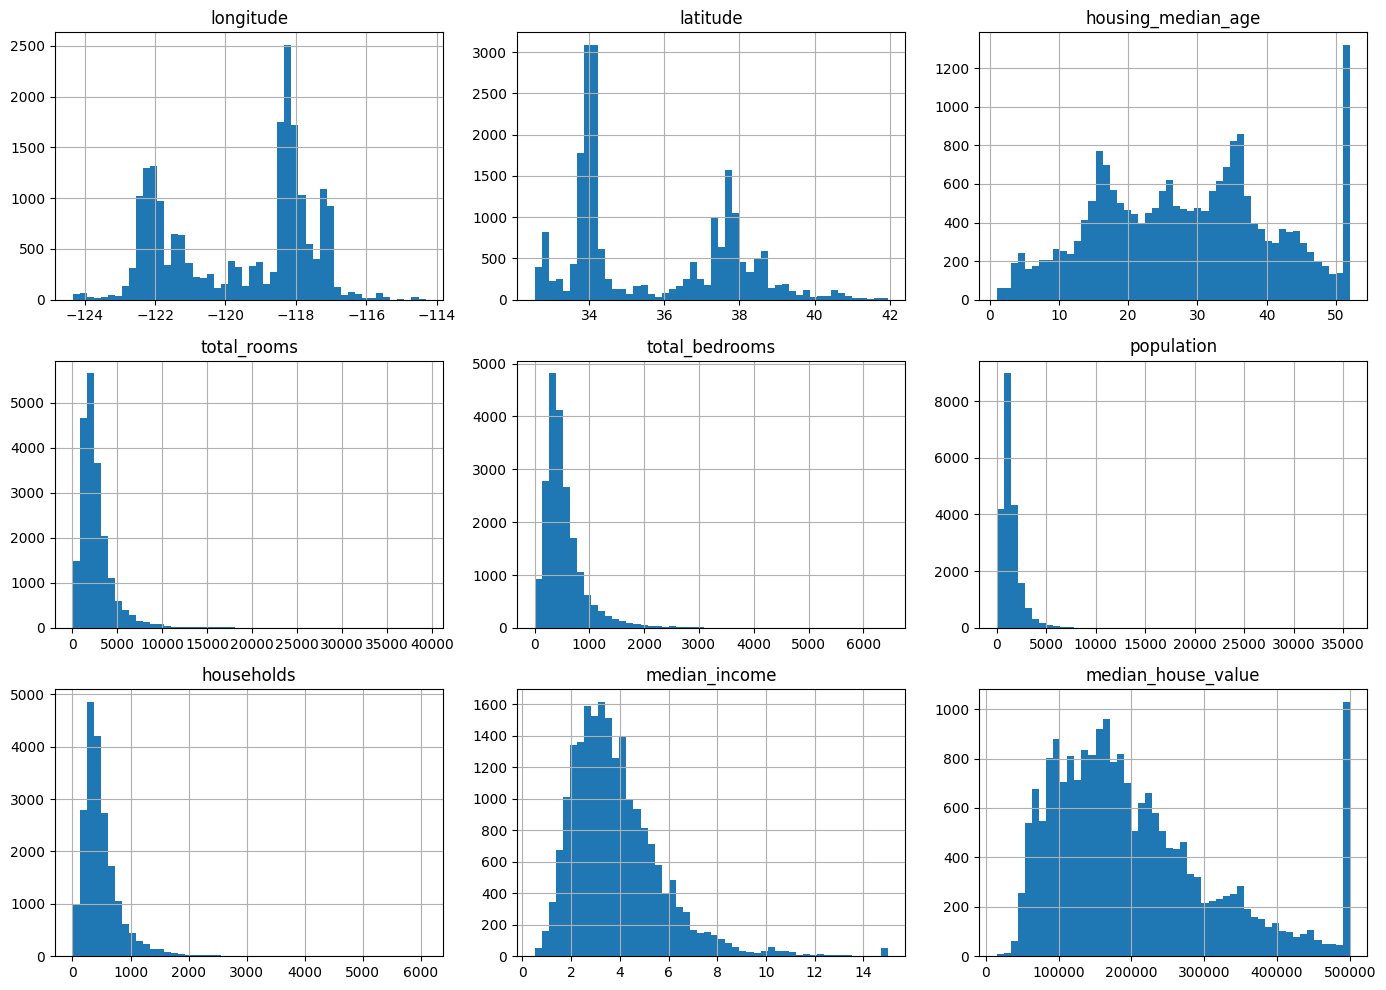

In [26]:
# Histograma de cada variable numérica, para ver forma y escala de las distribuciones
df.hist(bins=50, figsize=(14, 10))
plt.tight_layout()
plt.show()

**Conclusión:**

- `housing_median_age` es la única variable con forma casi simétrica.
- `total_rooms`, `total_bedrooms`, `population`, `households` y, en menor medida, `median_income` tienen cola larga a la derecha: la mayoría de los bloques tienen valores bajos o medios y unos pocos concentran valores muy altos.
- En el histograma de `median_house_value` se nota una barra más alta justo en el extremo derecho. Es el mismo tope de 500,001 que ya habíamos detectado con los números.

**Para pensar:** de las variables con cola larga a la derecha, ¿cuál te parece más problemática para un histograma con escala lineal, y por qué probarías una escala logarítmica en esa en particular?

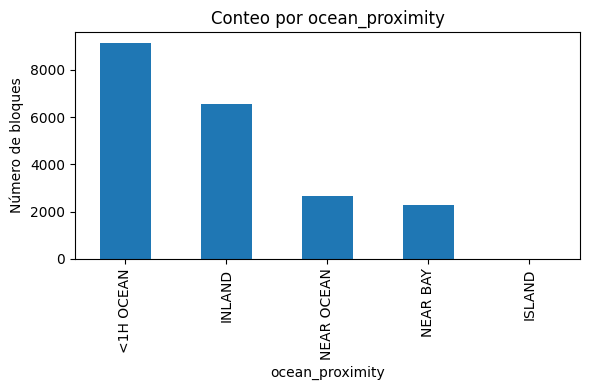

In [27]:
# Conteo de la variable categórica ocean_proximity
categorias_ocean.plot(kind="bar", figsize=(6, 4), title="Conteo por ocean_proximity")
plt.ylabel("Número de bloques")
plt.tight_layout()
plt.show()

**Conclusión:**

- El gráfico de barras hace evidente el desbalance que ya habíamos visto en la tabla: `ISLAND` es prácticamente invisible frente a las demás barras.
- Si en una sesión futura se colorea un gráfico por `ocean_proximity` (por ejemplo el mapa de California), hay que anticipar que `ISLAND` va a aportar muy pocos puntos y puede pasar desapercibida o generar una leyenda con una categoría casi vacía.

**Para pensar:** ¿qué tipo de gráfico usarías en lugar de barras si quisieras mostrar tanto el conteo como el porcentaje de cada categoría al mismo tiempo?

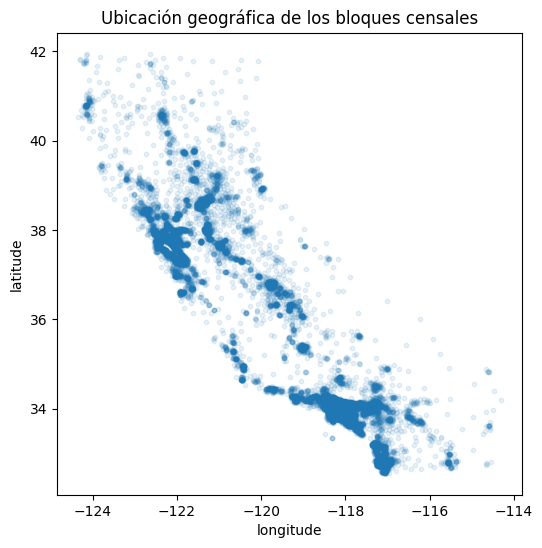

In [28]:
# Scatter longitude vs latitude: debería dibujar la forma de California
plt.figure(figsize=(6, 6))
plt.scatter(df["longitude"], df["latitude"], alpha=0.1, s=10)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Ubicación geográfica de los bloques censales")
plt.show()

**Conclusión:**

- Con solo `longitude` y `latitude` ya se distingue la silueta de California.
- Se nota mayor densidad de puntos (zonas más oscuras) a lo largo de la costa, y dos manchas densas que corresponden al área de la Bahía de San Francisco y al área de Los Ángeles y San Diego.
- Esto sugiere que la ubicación va a estar relacionada con `median_house_value`, algo que confirmamos en el siguiente gráfico.

**Para pensar:** ¿cómo modificarías este mismo scatter para que el color o el tamaño de cada punto representen `median_house_value`, y qué esperarías ver si la hipótesis anterior es correcta?

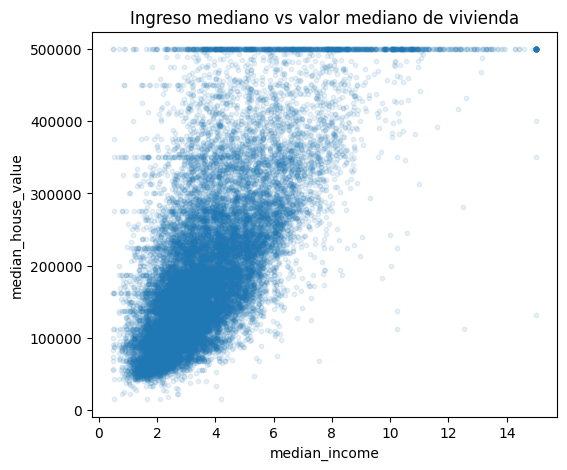

In [29]:
# Scatter median_income vs median_house_value: ¿hay relación visible con la variable objetivo?
plt.figure(figsize=(6, 5))
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.1, s=10)
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.title("Ingreso mediano vs valor mediano de vivienda")
plt.show()

**Conclusión:**

- Se ve una tendencia positiva clara (correlación de 0.69): a mayor `median_income`, mayor `median_house_value`.
- También se distingue una línea horizontal densa de puntos justo en 500,001 que atraviesa todo el rango de ingresos. Es la marca más directa del tope: sin importar cuánto gane el bloque, si el valor real superaba $500,001 quedó registrado igual.
- De las variables vistas hasta ahora, `median_income` muestra la relación más fuerte y visualmente más clara con la variable objetivo.

**Para pensar:** si tuvieras que elegir una sola variable para predecir `median_house_value` con este análisis, ¿elegirías `median_income`? ¿Qué otra variable combinarías con ella y por qué?

## 5. Preguntas guía

Antes de pasar a la siguiente sesión (limpieza de datos), responde estas preguntas con lo que encontraste en este notebook. No hay una única respuesta correcta, pero apóyate en los resultados concretos de arriba:

1. De las variables que viste, ¿cuáles parecen tener relación con `median_house_value`? ¿En qué celda de este notebook basas tu respuesta?
2. El tope en `median_house_value` (cerca de $500,001) afecta al 4.68% de las filas. ¿Qué harías con esas filas si tuvieras que entrenar un modelo: eliminarlas, dejarlas, o algo distinto? ¿Por qué?
3. `total_rooms`, `total_bedrooms`, `population` y `households` son valores absolutos por bloque, no por vivienda. Si quisieras comparar el tamaño típico de una vivienda entre bloques, ¿qué variable derivada (por ejemplo habitaciones por hogar) construirías, y por qué el valor absoluto no te serviría para eso?
4. Para cada una de estas variables (`ocean_proximity`, `median_house_value`, `longitude` y `latitude` juntas), ¿qué tipo de gráfico de los vistos en clase usarías para representarla, y por qué ese y no otro?
5. Este notebook solo usó las 10 columnas originales. Si pudieras cruzar este dataset con una fuente externa (por ejemplo distancia al centro de la ciudad más cercana, o tasa de criminalidad por zona), ¿qué variable agregarías y qué pregunta nueva te ayudaría a responder?

In [30]:
# Guardamos un resumen en texto con los hallazgos clave de calidad de datos, para retomarlo en la limpieza
resumen = f"""# Resumen de exploración inicial: California Housing

- Filas: {df.shape[0]}, columnas: {df.shape[1]}
- Nulos por columna:
{nulos_por_columna[nulos_por_columna > 0].to_string()}
- Filas duplicadas: {n_duplicados}
- Rango longitude: {df["longitude"].min()} a {df["longitude"].max()}
- Rango latitude: {df["latitude"].min()} a {df["latitude"].max()}
- Categorías de ocean_proximity:
{categorias_ocean.to_string()}
- Filas con median_house_value en el tope (>= {tope_house_value}): {n_en_tope} ({n_en_tope / len(df) * 100:.2f}%)
"""

with open(os.path.join("data", "resumen_exploracion.md"), "w", encoding="utf-8") as f:
    f.write(resumen)

print(resumen)

# Resumen de exploración inicial: California Housing

- Filas: 20640, columnas: 10
- Nulos por columna:
total_bedrooms    207
- Filas duplicadas: 0
- Rango longitude: -124.35 a -114.31
- Rango latitude: 32.54 a 41.95
- Categorías de ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
- Filas con median_house_value en el tope (>= 500001): 965 (4.68%)



**Conclusión:**

- El archivo `data/resumen_exploracion.md` queda guardado con estos hallazgos. Así, en la siguiente sesión (limpieza de datos) no hace falta volver a correr todo este notebook para recordar qué estaba pendiente: los 207 nulos de `total_bedrooms`, el tope en `median_house_value`, y el desbalance de `ISLAND` en `ocean_proximity`.

**Para pensar:** además de nulos, duplicados y topes, ¿qué otro hallazgo agregarías a ese resumen si tuvieras que retomarlo tú mismo en tres semanas y ya no recordaras nada de este notebook?

---

## 6. Taller: Caso de estudio Conecta

**Propósito:** aplicar el mismo flujo de exploración de este notebook (carga, calidad de datos, estadística descriptiva, visualizaciones, conclusiones basadas en resultados) a un dataset más exigente. California Housing es una foto fija de bloques censales; el dataset de Conecta es un panel mensual de usuarios de una empresa de telecomunicaciones, con jerarquía geográfica (región, ciudad, localidad) en vez de coordenadas sueltas. La técnica es la misma; el reto está en adaptarla a una estructura más compleja.

**Dataset:** `data/conecta_sa_usuarios_150k_panel.csv`

**Columnas:** `user_id, mes, pais, region, ciudad, localidad, tier_localidad, latitud, longitud, plan_type, signup_date, tenure_months, es_cliente_nuevo_mes, monthly_revenue_cop, data_usage_gb, complaints_month, nps_score, churned, churn_type, churn_date`

Con estos datos, realiza los siguientes puntos:

1. **Carga y estructura:** carga el csv y reporta filas, columnas y tipos de dato. A diferencia de housing, aquí cada usuario puede aparecer en varias filas (una por mes). ¿Cómo confirmas cuántos usuarios únicos hay realmente, y no solo cuántas filas tiene el archivo?
2. **Calidad de datos:** cuenta nulos por columna. Antes de asumir que un nulo es un error, pregúntate si esa columna aplica a todos los usuarios o solo a un subconjunto (por ejemplo, las columnas relacionadas con `churn`). Revisa también duplicados exactos, variantes de escritura en `region` y `plan_type` (mayúsculas, tildes, espacios), y coordenadas (`latitud`/`longitud`) fuera del rango de Colombia o en (0, 0).
3. **Estadística descriptiva:** calcula `.describe()` para las columnas numéricas. Presta especial atención a `nps_score`: ¿tiene valor en todas las filas o falta en una proporción alta? Si falta mucho, ¿parece un patrón aleatorio o depende de otra columna, como si el usuario churneó ese mes?
4. **Visualizaciones:** distribución de usuarios por `region` y por `tier_localidad`, evolución mensual de altas y churn, relación entre `complaints_month` y `data_usage_gb`.
5. **Conclusiones propias:** para cada punto anterior, una conclusión basada en tus propios números y gráficos, no una descripción genérica de la técnica.
6. **Comparación con housing:** ¿qué problema de calidad de datos se parece a algo que viste en California Housing (nulos, categorías desbalanceadas)? ¿Y qué es completamente nuevo aquí (estructura de panel, texto con variantes, jerarquía geográfica) que no existía en housing?